### Light Curve Analysis of TOI-700d

**TOI-700d** is one the confirmed plants discovered from time-series data collected from TESS Exoplanet mission.  
This Notebook is intended to provide preprocessing for noise removal and building a one dimensional Convolutional Neural Network using **PyTorch** to classify the light curve into four classes followed by demonstration of converting into a ML Pipeline.

**Classes**
* Transit
* Stellar Variability
* Eclipsing Binary
* Background Artifact



In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from scipy.interpolate import interp1d
import lightkurve as lk
from transitleastsquares import transitleastsquares
import astropy.units as u
from astropy.timeseries import BoxLeastSquares

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchviz import make_dot

TIC_ID = "TIC 150428135"

%matplotlib inline

## Summary of Glossary 
**TIC (TESS Information Catalog):**  
- Provides ID's which allows us to obtain a TPF from the MAST Archive via *lightkurve* library.

**TESS Target Pixel File (TPF)**  
- A file containing the original CCD pixel observations from which light curves are extracted.
- Postage stamp cut outs from the FFI, focused on a selected target of interest. Each stamp has a cadence of 2-min or 20-sec.
- Typically stored in *.fits* file format.

**Cadence**  
- Each time-stamp with its corresponding image in a TPF is called a **Cadence**.
- The rate at which TESS Photometric observations are stored.

**Light Curve Files**  
- One of the main data products collected by TESS mission are called **Light Curve Files**
- It is time-series data produced for each 2-min or 20-sec TPF object.

**Combined Differential Photometric Precision (CDPP):**  
- Typically measured in *parts-per-million (ppm)*, it is used to quantify the noise level in    stellar light curves over a specific timescale. The primary value of CDPP is its ability to predict the detectability of transiting exoplanets.  
- **Lower CDPP** value indicates **higher precision** and **less noise**, allowing astronomers to detect smaller planets passing infront of their host stars.  
- It effectively combines various noise sources like stellar variability, instrument noise into a single performance metric.

**LightCurveObject**  
- Obtained from a TPF and contains light curve information derived using *Simple Aperture Photometry(SAP)*

**Simple Aperture Photometry Flux (SAPF):**  
- Flux calculated using SAP. The SAP light curve is calculated by summing together the brightness of pixels that fall within an aperture set by the TESS Mission.
- Since SAP is sum of the brightness of chosen pixels, it is still subject to systematic artifacts of the mission.

**LightCurveFileObject**  
- Obtained from MAST and contains both SAPF and PDCSAPF.

**Pre-Search Data Conditioning SAP Flux (PDCSAPF)**  
- SAP Flix from which long term trends have been removed using so-called **Co-trending Basis Vector (CBV's)**.
- This flux is usually cleaner than the SAP Flux and will have fewer systematic trends.
****

In [2]:
search_tpf = lk.search_targetpixelfile(TIC_ID, mission="TESS", author="SPOC")
for _ in search_tpf[:5]:
    print(_)

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   150428135      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 03 2018   SPOC     120   150428135      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 04 2018   SPOC     120   150428135      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 

In [3]:
tpf = search_tpf[1].download(quality_bitmask='default')
tpf

TessTargetPixelFile(TICID: 150428135)

<Axes: title={'center': 'Target ID: 150428135, Cadence: 114106'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

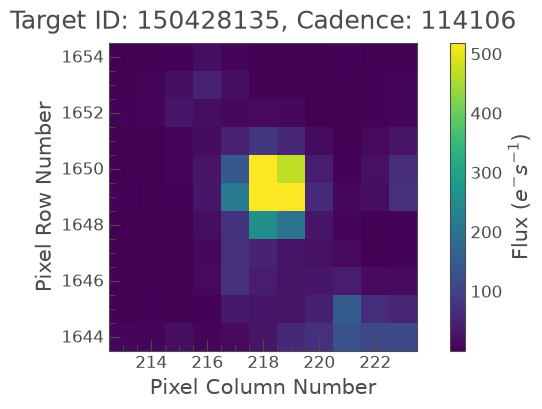

In [4]:
tpf.plot()

In [5]:
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask) # to_lightcurve() returns SAPF by default
lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
1385.9356910156823,5753.34716796875,9.027629852294922,218.25564369665713,1649.2462941454448,114106,8192
1385.937079908638,5752.7431640625,9.029905319213867,218.24523426159504,1649.2489164211147,114107,8192
1385.9384688015934,5742.66162109375,9.033260345458984,218.23810779460194,1649.2646968526503,114108,8192
1385.9398576945482,5739.88671875,9.020593643188477,218.2368397198935,1649.2645550274108,114109,8192
1385.9412465875037,5749.98828125,9.024652481079102,218.2326126493942,1649.2712223259934,114110,8192
1385.9426354804302,5765.1923828125,9.034281730651855,218.22652580999048,1649.2694632130256,114111,8192
1385.944024373385,5751.56396484375,9.024114608764648,218.22894712852178,1649.2652573525666,114112,8192
1385.9454132663398,5759.95654296875,9.029462814331055,218.23364960003974,1649.2702014546494,114113,8192


In [6]:
cdpp_before = lc.estimate_cdpp()
print(f'The CCDP Value before pre-processing: {cdpp_before:.2f}')

The CCDP Value before pre-processing: 400.88 ppm


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

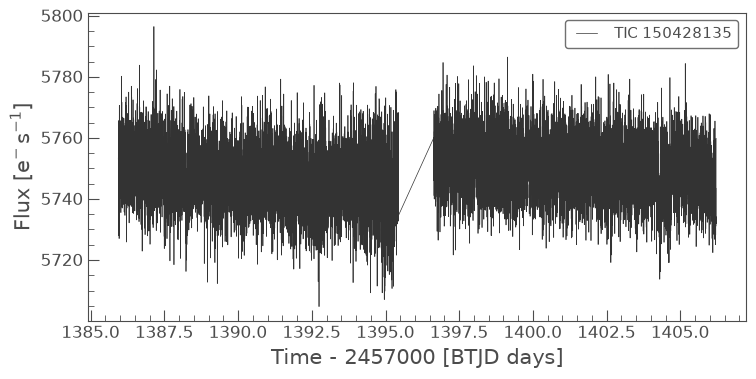

In [7]:
lc.plot()

### Pre-Processing

There are some inbuilt functions which allows us to deal with noise in the time-series data.  
As seen in the above plot, the data is messy with outliers and its very hard to detect depths.

There are various kinds of noise which accounts for irregular data,
- Instrumental Noise such as background sources in the aperture
- Brightness Variations due to transiting planets
- Intrinsic Noise in the data due to detector's response to name a few

Funtions which helps us lowering the noise are as follows,
- *flatten()*:  
  Remove long term trends using a **Savitzky-Golay Filter**  
- *remove_outliers()*:  
  Remove outliers using simple sigma clipping  
- *remove_nans()*:  
  Remove infinite or NaN values
- *fold()*:  
  Fold the data at a particular period. Useful to detect transit depths at phase 0.0 or 1.0
- *bin()*:  
  Reduce the time resolution of the array, taking the average value in each bin

We mainly concern ourselves with *time* and *flux* given in *Light Curve File*.  
Using PDCSAP Flux all the instrumental noise are minimized and is preferred.

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

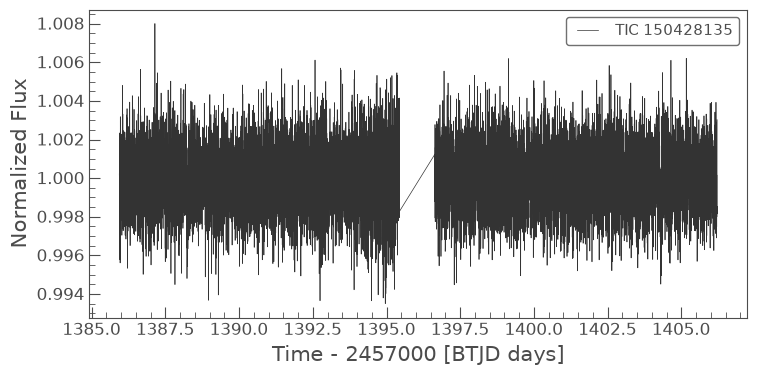

In [8]:
lcc = lc.copy()
lcc = lcc.flatten(window_length=401)
lcc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

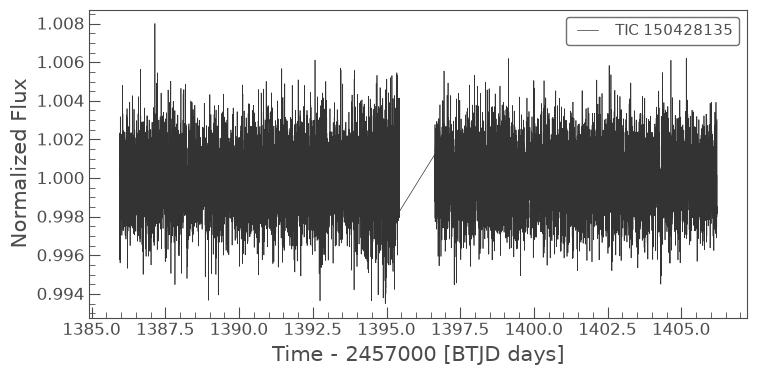

In [9]:
lcc = lcc.remove_outliers().normalize()
lcc.plot()

The **GlobalSearch** class contains methods which calculates optimal parameters such as *orbital period, transit_depth, transit_duration, sde and epoch* using various methods such as *Transit Least Squares* and *Box Least Squares*.

- *constructor GlobalSearch(self, time.value, flux.value)*
- *method **EvaulateParams(self, method='tls or bls', plot=False(default) or True)** Evaulates parameters returns void*  
- *method **getParams(self)** returns a numpy array with required parameters i.e, orbital period, transit_duration and transit_depth*  
- *method **TransitLeastSquares(self, plot=False(default) or True)** Evaluates parameters using Transit Least Squares return void*  
- *method **BoxLeastSquares(self, plot=False(default) or True)** Evaluates parameters using Box Least Squares return void*

In [10]:
class GlobalSearch:
    def __init__(self, t, f):
        self.t = t
        self.f = f
        self.period = None
        self.transit_duration = None
        self.transit_depth = None
        self.sde = None
        self.epoch = None

    def EvaluateParams(self, method='tls', plot=False):
        if method == 'tls':
            self.TransitLeastSquares()
        if method == 'bls':
            self.BoxLeastSquares()
    
    def getParams(self):
        return np.array([self.period, self.transit_duration, self.transit_depth])

    def TransitLeastSquares(self, plot=False):
        model = transitleastsquares(self.t, self.f)
        res = model.power()
        self.period = res.period
        self.transit_duration = res.duration
        self.transit_depth = res.depth
        self.sde = res.SDE
        self.epoch = res.T0
        

    def BoxLeastSquares(self):
        model = BoxLeastSquares(self.t, self.f)
        res = model.autopower(0.16)
        best_idx = np.argmax(res.power)
        self.period = res.period[best_idx]
        self.transit_duration = res.duration[best_idx]
        self.transit_depth = res.depth[best_idx]
        self.sde = res.power[best_idx]
        self.epoch = res.transit_time[best_idx]

In [11]:
gs = GlobalSearch(lcc.time.value, lcc.flux.value)
gs.EvaluateParams(method="tls")

gs_bls = GlobalSearch(lcc.time.value, lcc.flux.value)
gs_bls.EvaluateParams(method="bls")

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 36 durations
Searching 13541 data points, 1745 periods from 0.602 to 10.139 days
Using all 12 CPU threads


100%|█████████████████████████████████████████████████| 1745/1745 periods | 00:14<00:00


Searching for best T0 for period 8.03277 days


100%|██████████████████████████████████████████| 13541/13541 [00:03<00:00, 4253.93it/s]
/home/irala-rushendra/miniconda3/envs/roboml/lib/python3.14/site-packages/transitleastsquares/main.py:411: UserWarning: 1 of 3 transits without data. The true period may be twice the given period.
  warnings.warn(text)


In [12]:
params = gs.getParams() * 2
params_bls = gs_bls.getParams()
params_bls

array([9.41170445e+00, 1.60000000e-01, 7.72386637e-04])

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

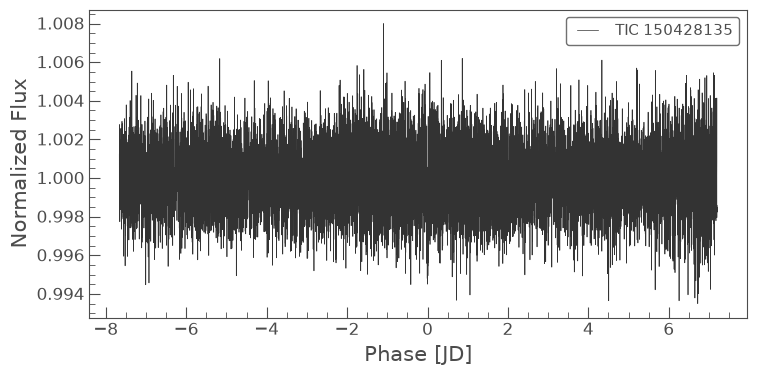

In [13]:
lcc = lcc.fold(period=params[0], epoch_time=gs.epoch)
lcc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

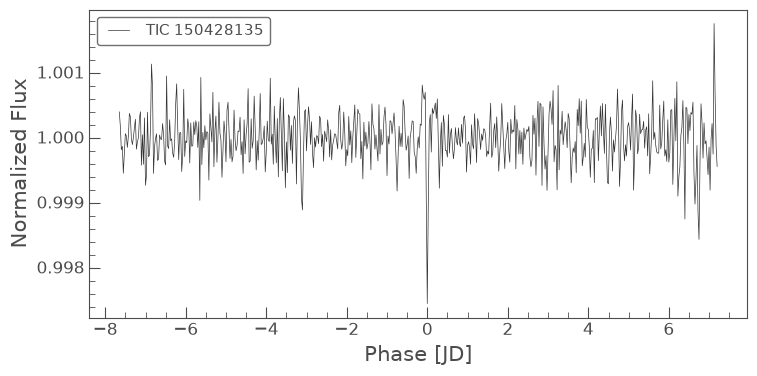

In [14]:
lcc = lcc.bin(time_bin_size=0.025)
lcc.plot()

### Summary from the picture

- Now our transit is clearly visible in comparision with the original plot.
- The sharp 'V' suggests a planetary transit.
- The depth of the dip corresponds to size of exoplanet relative to the star and can be identified as TOI-700c as it is the largest confirmed exoplanet in the host-star system.
- Other dips relatively that are small suggests the remaining planets.


In [15]:
cdpp_after = lcc.estimate_cdpp()
print(f'CDPP Value after pre-processing: {cdpp_after:.2f}')

CDPP Value after pre-processing: 62.29 ppm


### We have worked with LightCurveObject which uses SAPF by default. Now we will use LightCurveFile which uses PDCSAPF by default.

In [16]:
search_lcv = lk.search_lightcurve(TIC_ID, author="SPOC", exptime=120)
search_lcv[1]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 03,2018,SPOC,120,150428135,0.0


In [17]:
lcf = search_lcv[1].download()
lcf

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1385.9356910156823,6.6202646e+03,1.0891523e+01,-2.9158429e-04,114106,218.25565,1649.24638,5.7533472e+03,9.4442472e+00,9.0436566e+02,2.9241729e+00,6.6202646e+03,1.0891523e+01,10000000000000,———,———,———,———,218.25565,9.5205678e-04,1649.24638,1.1640688e-03,3.2457724e-02,3.1395838e-02
1385.937079908638,6.6157886e+03,1.0896415e+01,-2.9157966e-04,114107,218.24521,1649.24875,5.7527437e+03,9.4484873e+00,9.0496490e+02,2.9315755e+00,6.6157886e+03,1.0896415e+01,10000000000000,———,———,———,———,218.24521,9.5127436e-04,1649.24875,1.1669960e-03,2.0415343e-02,3.6151409e-02
1385.9384688015934,6.6009897e+03,1.0898334e+01,-2.9157504e-04,114108,218.23812,1649.26477,5.7426616e+03,9.4501524e+00,9.0962598e+02,2.9260449e+00,6.6009897e+03,1.0898334e+01,10000000000000,———,———,———,———,218.23812,9.5084932e-04,1649.26477,1.1702528e-03,1.2486253e-02,5.1640760e-02
1385.9398576945482,6.5982759e+03,1.0883720e+01,-2.9157041e-04,114109,218.23684,1649.26455,5.7398867e+03,9.4374809e+00,9.0882111e+02,2.9240277e+00,6.5982759e+03,1.0883720e+01,10000000000000,———,———,———,———,218.23684,9.5094339e-04,1649.26455,1.1662355e-03,1.2663547e-02,5.3322781e-02
1385.9412465875037,6.6088003e+03,1.0887943e+01,-2.9156578e-04,114110,218.23261,1649.27119,5.7499883e+03,9.4411430e+00,9.0748700e+02,2.9232442e+00,6.6088003e+03,1.0887943e+01,10000000000000,———,———,———,———,218.23261,9.4880944e-04,1649.27119,1.1662451e-03,7.8067775e-03,5.7231646e-02
1385.9426354804302,6.6251533e+03,1.0903137e+01,-2.9156118e-04,114111,218.22654,1649.26959,5.7651924e+03,9.4543171e+00,9.0889331e+02,2.9374714e+00,6.6251533e+03,1.0903137e+01,10000000000000,———,———,———,———,218.22654,9.4589783e-04,1649.26959,1.1618290e-03,8.7311980e-04,5.5909432e-02
1385.944024373385,6.6114556e+03,1.0886950e+01,-2.9155656e-04,114112,218.22894,1649.26523,5.7515640e+03,9.4402819e+00,9.0592908e+02,2.9220033e+00,6.6114556e+03,1.0886950e+01,10000000000000,———,———,———,———,218.22894,9.4799965e-04,1649.26523,1.1660462e-03,1.6979050e-03,5.0762311e-02
1385.9454132663398,6.6195840e+03,1.0891454e+01,-2.9155193e-04,114113,218.23364,1649.27010,5.7599570e+03,9.4441862e+00,9.0205286e+02,2.9176600e+00,6.6195840e+03,1.0891454e+01,10000000000000,———,———,———,———,218.23364,9.4622833e-04,1649.27010,1.1651415e-03,7.0210234e-03,5.5652089e-02


In [18]:
cdpp_before_ = lcf.estimate_cdpp()
print(f'CDPP Value before Pre-Processing : {cdpp_before_:.2f}')

CDPP Value before Pre-Processing : 383.69 ppm


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

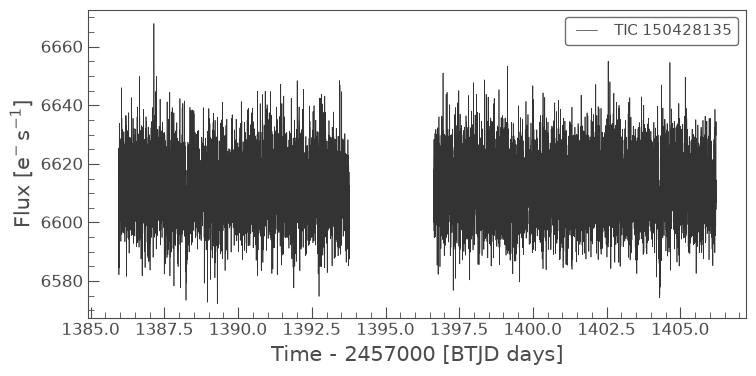

In [19]:
lcf.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized sap_flux'>

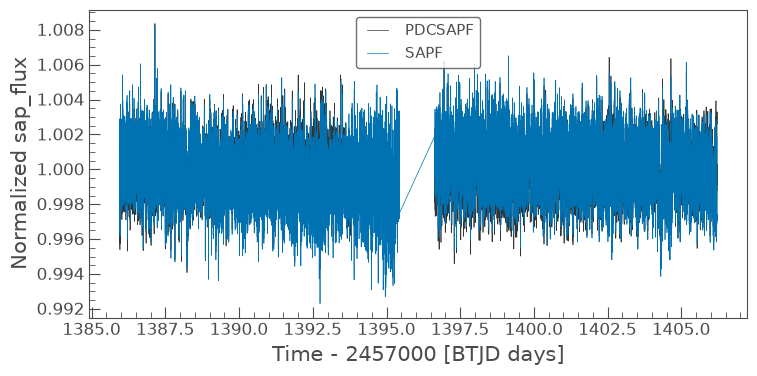

In [20]:
# SAPF and PDCSAPF Comparision
ax = lcf.plot(label='PDCSAPF', normalize=True)
lcf.plot(column='sap_flux', normalize=True, label='SAPF', ax=ax)

Text(0.5, 1.0, 'PDCSAPF Light Curve of TOI-700 c')

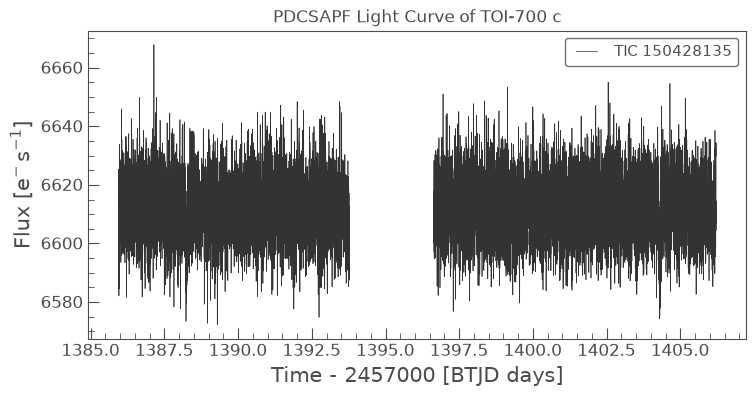

In [21]:
ax = lcf.plot()
ax.set_title("PDCSAPF Light Curve of TOI-700 c")

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

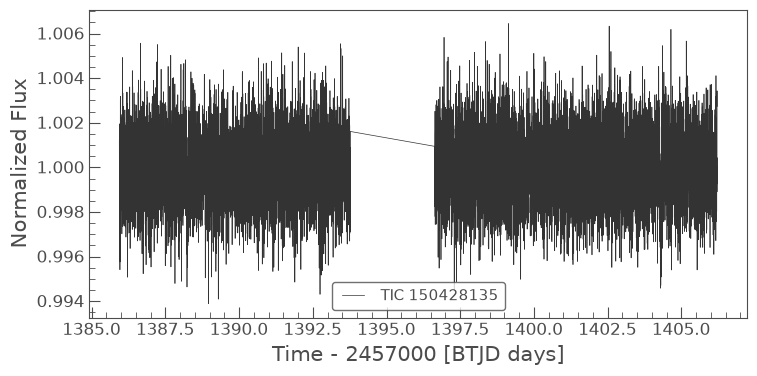

In [22]:
lcf = lcf.flatten(window_length=401).remove_outliers().remove_nans()
lcf.plot()

In [23]:
gs_pdcsap = GlobalSearch(lcf.time.value, lcf.flux.value)
gs_pdcsap.EvaluateParams()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 36 durations
Searching 12378 data points, 1745 periods from 0.602 to 10.139 days
Using all 12 CPU threads


100%|█████████████████████████████████████████████████| 1745/1745 periods | 00:14<00:00


Searching for best T0 for period 8.03277 days


100%|██████████████████████████████████████████| 12378/12378 [00:02<00:00, 5005.52it/s]
/home/irala-rushendra/miniconda3/envs/roboml/lib/python3.14/site-packages/transitleastsquares/main.py:411: UserWarning: 1 of 3 transits without data. The true period may be twice the given period.
  warnings.warn(text)


In [24]:
params_ = gs_pdcsap.getParams()
params_

array([8.03277243, 0.03448004, 0.99762614])

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

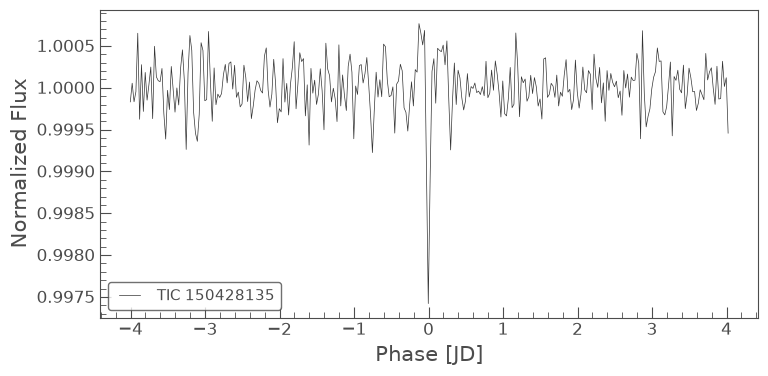

In [25]:
lcf = lcf.fold(period=params_[0], epoch_time=gs_pdcsap.epoch).bin(time_bin_size=0.025)
lcf.plot()

In [26]:
cdpp_after_ = lcf.estimate_cdpp()
print(f'CDPP Value after Pre-Processing : {cdpp_after_:.2f}')

CDPP Value after Pre-Processing : 52.26 ppm


### Comparision of plots of same system with SAP and PDCSAP

(<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>,
 <Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>)

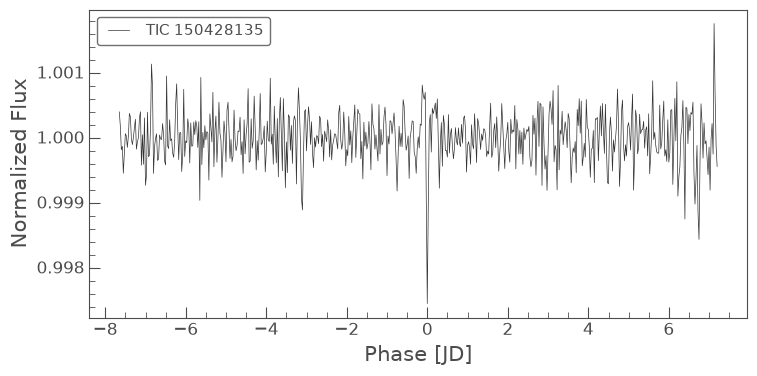

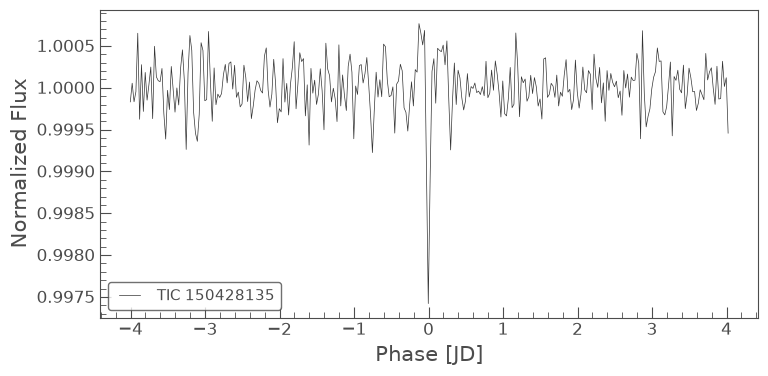

In [27]:
lcc.plot(), lcf.plot()

### Building an CNN Classifier using Pytorch

- *Constructor **LightCurveClassifier(self, global_length=np.int, local_length=np.int, model=ExoplanetDualBranch)***  
- *method **Transform(self, folded_lc=TessLightCurve(), global_length=np.int, local_length=np.int, fluxt='pdcsap or sap')** sets global and local tensors; returns void*
- *method **ClassifySignal(self, report=False(default) or True** returns pred_class_idx, probabilities*

In [28]:
class LightCurveClassifier:
    def __init__(self, model):
        self.global_tensor = None
        self.local_tensor = None
        self.model = model

    """Inputs are structured for the Neural Network to process"""
    def Transform(self, folded_lc, global_length=2001, local_length=201, fluxt='pdcsap', ret=False):
        folded_lc = folded_lc.remove_nans()
        time = folded_lc.time.value
        flux = folded_lc.flux.value

        if fluxt != 'pdcsap':
            flux = folded_lc.sap_flux.value

        flux_norm = (flux - np.mean(flux)) / np.std(flux)
        phase_grid_global = np.linspace(np.min(time), np.max(time), global_length)
        interpolator = interp1d(time, flux_norm, kind='linear', fill_value='extrapolate')
        global_view = interpolator(phase_grid_global)

        center_idx = global_length // 2
        half_window = local_length // 2
        start_idx = center_idx - half_window
        end_idx = center_idx + half_window + 1

        local_view = global_view[start_idx: end_idx]

        self.global_tensor = torch.tensor(global_view, dtype=torch.float32).view(1,1,global_length)
        self.local_tensor = torch.tensor(local_view, dtype=torch.float32).view(1,1,local_length)

        if ret:
            return self.global_tensor, self.local_tensor

    def Predict(self, report=False):

        classes = {
            0 : "Transit",
            1 : "Eclipse Binary",
            2 : "Background Artifact",
            3 : "Stellar Variability"
        }

        self.model.eval()

        with torch.no_grad():
            raw_outputs = self.model(self.global_tensor, self.local_tensor)
            probabilities = f.softmax(raw_outputs, dim=1).squeeze().numpy()

        pred_class_idx = np.argmax(probabilities)
        pred_label = classes[pred_class_idx]
        conf = probabilities[pred_class_idx] * 100
            
        def getReport(label, conf, prob, classes):
            print("###AI Classifier Report###\n")
            print("-----------------------------")
            print(f"Primary Detection : {label}")
            print(f"Confidence Level  : {conf:.2f}%\n")
            print("-----------------------------")
            print("###Probabilities###\n")
            for i, prob in enumerate(probabilities):
                print(f"{classes[i]:<28}: {prob*100:>6.2f}%")

        if report:
            getReport(pred_label, conf, probabilities, classes)

        return pred_class_idx, probabilities
    

In [29]:
class ExoplanetDualBranchCNN(nn.Module):
    def __init__(self, global_length=2001, local_length=201, num_classes=4):
        super(ExoplanetDualBranchCNN, self).__init__()

        # Global View Branch
        self.global_conv1_1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.global_conv1_2 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=5, padding=2)
        self.global_pool1 = nn.MaxPool1d(kernel_size=5, stride=2)
        self.global_bn1 = nn.BatchNorm1d(16)

        self.global_conv2_1 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.global_conv2_2 = nn.Conv1d(in_channels=32, out_channels=32, kernel_size=5, padding=2)
        self.global_pool2 = nn.MaxPool1d(kernel_size=5, stride=2)
        self.global_bn2 = nn.BatchNorm1d(32)
        
        self.global_conv3_1 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.global_conv3_2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5, padding=2)
        self.global_pool3 = nn.MaxPool1d(kernel_size=5, stride=2)

        #Local View Branch
        self.local_conv1_1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.local_conv1_2 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=5, padding=2)
        self.local_pool1 = nn.MaxPool1d(kernel_size=5, stride=2)
        self.local_bn1 = nn.BatchNorm1d(16)
    
        self.local_conv2_1 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.local_conv2_2 = nn.Conv1d(in_channels=32, out_channels=32, kernel_size=5, padding=2)
        self.local_pool2 = nn.MaxPool1d(kernel_size=5, stride=2)

        with torch.no_grad():
            dummy_global = torch.zeros(1,1,global_length)
            dummy_local = torch.zeros(1,1,local_length)
            flat_global_dim = self._forward_global(dummy_global).shape[1]
            flat_local_dim = self._forward_local(dummy_local).shape[1]

        combined_dim = flat_global_dim + flat_local_dim

        self.fc1 = nn.Linear(combined_dim, 512)
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(p=0.3)
        self.fc3 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, num_classes)

    def _forward_global(self, x):
        x = F.relu(self.global_conv1_1(x))
        x = F.relu(self.global_conv1_2(x))
        x = self.global_pool1(x)
        x = self.global_bn1(x)

        x = F.relu(self.global_conv2_1(x))
        x = F.relu(self.global_conv2_2(x))
        x = self.global_pool2(x)
        x = self.global_bn2(x)

        x = F.relu(self.global_conv3_1(x))
        x = F.relu(self.global_conv3_2(x))
        x = self.global_pool3(x)
        return torch.flatten(x, start_dim=1)

    def _forward_local(self, x):
        x = F.relu(self.local_conv1_1(x))
        x = F.relu(self.local_conv1_2(x))
        x = self.local_pool1(x)
        x = self.local_bn1(x)

        x = F.relu(self.local_conv2_1(x))
        x = F.relu(self.local_conv2_2(x))
        x = self.local_pool2(x)
        return torch.flatten(x, start_dim=1)

    def forward(self, global_input, local_input):
        x1 = self._forward_global(global_input)
        x2 = self._forward_local(local_input)
        merged = torch.cat((x1,x2), dim=1)

        z = F.relu(self.fc1(merged))
        z = self.dropout1(z)
        z = F.relu(self.fc2(z))
        z = self.dropout2(z)
        z = F.relu(self.fc3(z))

        return self.fc_out(z)

In [39]:
gl_inp = torch.randn(1,1,2001,requires_grad=True)
lc_inp = torch.randn(1,1,201,requires_grad=True)

out = ExoplanetDualBranchCNN(gl_inp, lc_inp)
dot = make_dot(out, params=dict(model.named_parameters()))
dot.render("CNN Architecture", format='png', cleanup=True)

TypeError: zeros(): argument 'size' failed to unpack the object at pos 3 with error "type must be tuple of ints,but got Tensor"

### Dummy Execution 

<h4>Since this is an untrained classifier, it shows almost equal probabilities for all the four classes</h4>

In [38]:
model = ExoplanetDualBranchCNN(global_length=2001, local_length=201, num_classes=4)
classifier = LightCurveClassifier(model)
period = 3.67676
epoch = 67.54432
folded_lc = lc.fold(period=period, epoch_time=epoch)

classifier.Transform(folded_lc)
pred, probs = classifier.Predict(report=True)


###AI Classifier Report###

-----------------------------
Primary Detection : Background Artifact
Confidence Level  : 26.59%

-----------------------------
###Probabilities###

Transit                     :  25.05%
Eclipse Binary              :  23.87%
Background Artifact         :  26.59%
Stellar Variability         :  24.48%
